In [1]:
import sys
from pathlib import Path

TASK_DIR = Path("/work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-electrolyte-small2").resolve()
ROOT_DIR = TASK_DIR.parent  # .../CACE-SOG-Qeq（含 cace 包）
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from ase.io import read
import cace
import torch
import numpy as np
from torch import nn
from cace.tools.scatter import scatter_sum
from cace.tools import torch_geometric
from cace.data.extxyz_charge import read_extxyz_with_charge

# 兼容旧 checkpoint：训练脚本中的自定义模块，load 前需在 __main__ 定义
class FixedElementwiseFeatureBias(nn.Module):
    """
    Fixed (non-trainable) elementwise bias + global scale:
        chi_biased = scale * chi + bias[element]
    """
    def __init__(
        self,
        elements,
        feature_key: str,
        output_key: str,
        init_bias: dict,
        init_scale: float = 5.0,
        atomic_numbers_key: str = "atomic_numbers",
    ):
        super().__init__()
        self.elements = [int(z) for z in elements]
        self.feature_key = feature_key
        self.output_key = output_key
        self.atomic_numbers_key = atomic_numbers_key
        self.model_outputs = [output_key]

        z_to_idx = {int(z): i for i, z in enumerate(self.elements)}
        self._z_to_idx = z_to_idx

        bias0 = torch.zeros(len(self.elements), dtype=torch.get_default_dtype())
        for z, v in init_bias.items():
            z_int = int(z)
            if z_int in z_to_idx:
                bias0[z_to_idx[z_int]] = float(v)

        # Fixed buffers (not nn.Parameter): no optimization updates.
        self.register_buffer("bias", bias0)
        self.register_buffer("scale", torch.tensor(float(init_scale), dtype=torch.get_default_dtype()))

    def forward(self, data: dict, **kwargs):
        if self.feature_key not in data:
            raise KeyError(f"FixedElementwiseFeatureBias: missing `{self.feature_key}` in data")
        if self.atomic_numbers_key not in data:
            raise KeyError(
                f"FixedElementwiseFeatureBias: missing `{self.atomic_numbers_key}` in data"
            )

        feat = data[self.feature_key]
        if feat.dim() == 1:
            feat = feat.unsqueeze(1)

        z = data[self.atomic_numbers_key].view(-1)
        idx = torch.empty_like(z, dtype=torch.long)
        for z_val, i in self._z_to_idx.items():
            idx[z == z_val] = int(i)

        feat_out = self.scale * feat + self.bias[idx].unsqueeze(1)
        data[self.output_key] = feat_out
        return data

# 兼容旧 checkpoint：该类训练时定义在脚本 __main__，加载时必须先在当前 __main__ 提供同名类
class SystemChargeFromAtomicCharges(nn.Module):
    """将每结构总电荷写入 data['system_charge']。"""
    def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
        super().__init__()
        self.charges_key = charges_key
        self.output_key = output_key
        self.model_outputs = [output_key]

    def forward(self, data: dict, **kwargs):
        if self.charges_key not in data or data[self.charges_key] is None:
            if data.get("batch", None) is None:
                num_graphs = 1
            else:
                num_graphs = int(data["batch"].max().item()) + 1 if data["batch"].numel() > 0 else 1
            data[self.output_key] = torch.zeros((num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype)
            return data

        q = data[self.charges_key]
        if q.dim() > 1:
            q = q.view(-1)
        if data.get("batch", None) is None:
            system_q = q.sum().view(1)
        else:
            system_q = scatter_sum(q, data["batch"], dim=0)
        data[self.output_key] = system_q
        return data

MODEL_PATH = TASK_DIR / "best_model.pth"
DATA_PATH = TASK_DIR / "electrolyte_200.xyz"
print("ROOT_DIR:", ROOT_DIR)
print("model:", MODEL_PATH)
print("data:", DATA_PATH)

model = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
model.eval()

# 保留 ASE 数据（仅用于某些可视化/兼容）
data = read(str(DATA_PATH), ":")

# 关键修正：评估必须走带 charge 的数据管线，避免 EvaluateTask(list[Atoms]) 丢失 charge
z_map = {"H": 1, "O": 8, "F": 9, "K": 19}
# 该数据集使用 extxyz header 的总能量，不做 atomic_energies 扣除
atomic_energies = None
cutoff = float(model.models[0].representation.cutoff) if hasattr(model, "models") else float(model.representation.cutoff)

data_with_charge = read_extxyz_with_charge(
    path=str(DATA_PATH),
    cutoff=cutoff,
    atomic_energies=atomic_energies,
    z_map=z_map,
)
print("num structures (with charge):", len(data_with_charge))


def evaluate_model_on_atomicdata(model, dataset, batch_size=8, device="cpu"):
    loader = torch_geometric.dataloader.DataLoader(
        dataset, batch_size=batch_size, shuffle=False, drop_last=False
    )
    energies, forces = [], []
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)
        if "CACE_energy" not in out or "CACE_forces" not in out:
            raise KeyError(f"missing keys in model output: {list(out.keys())}")
        energies.append(out["CACE_energy"].detach().cpu().numpy().reshape(-1))
        forces.append(out["CACE_forces"].detach().cpu().numpy())
    return {
        "energy": np.concatenate(energies, axis=0),
        "forces": np.concatenate(forces, axis=0),
    }


ROOT_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq
model: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-electrolyte-small2/best_model.pth
data: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-electrolyte-small2/electrolyte_200.xyz
num structures (with charge): 200


In [2]:
import numpy as np

def load_ref_energy_forces_from_extxyz(path, atomic_energies, z_map):
    energies, atom_nums, forces_blocks = [], [], []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            header = f.readline().strip()
            energy = None
            if "energy=" in header:
                try:
                    e_str = header.split("energy=")[1].split()[0]
                    energy = float(e_str)
                except Exception:
                    energy = None
            species, fl = [], []
            for _ in range(nat):
                parts = f.readline().split()
                species.append(parts[0])
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                fl.append(vals[3:6])
            Z = [z_map[s] for s in species]
            if energy is not None and atomic_energies is not None:
                energy -= sum(atomic_energies.get(int(z), 0.0) for z in Z)
            if energy is None:
                raise ValueError("no energy= in frame header")
            energies.append(energy)
            atom_nums.append(nat)
            forces_blocks.append(np.asarray(fl, dtype=np.float64))
    ref_energy = np.asarray(energies, dtype=np.float64)
    atom_num = np.asarray(atom_nums, dtype=np.float64)
    ref_force = np.concatenate(forces_blocks, axis=0)
    return ref_energy, atom_num, ref_force

In [3]:
# 与 cell0 中保持一致
z_map = {"H": 1, "O": 8, "F": 9, "K": 19}
atomic_energies = None
ref_energy, atom_num, ref_force = load_ref_energy_forces_from_extxyz(
    str(DATA_PATH), atomic_energies, z_map
)

In [4]:
pre = evaluate_model_on_atomicdata(model, data_with_charge, batch_size=8, device="cpu")
pre["energy"]

array([-192.09297 ,  -48.05443 , -195.76105 ,  -37.199486,  -27.777998,
        -74.8181  ,  -60.681385, -113.58532 ,  -67.13632 ,  -39.467667,
        -55.634888,  -36.099895,  -68.78092 ,  -47.000816,  -67.804405,
        -64.12929 , -114.55759 ,  -73.692055,  -75.22992 ,  -27.390053,
        -48.73367 ,  -73.49595 ,  -73.87045 ,  -75.1742  ,  -55.106792,
       -194.66884 ,  -26.82009 , -107.26099 ,  -74.47599 ,  -26.569584,
        -26.912628, -121.28731 ,  -74.95752 ,  -65.83079 , -121.26253 ,
        -73.43169 ,  -29.49435 ,  -37.284058,  -38.249134,  -64.98473 ,
        -47.125755, -196.4902  ,  -45.605743,  -55.609753, -197.12834 ,
        -47.01793 ,  -55.24006 ,  -67.10953 , -193.27011 , -194.87955 ,
        -67.331154,  -57.05969 , -121.33322 ,  -39.27759 ,  -65.83576 ,
        -38.047066,  -27.495972, -115.028564, -110.24258 , -110.81471 ,
        -46.16195 ,  -37.88109 ,  -66.425026, -114.74662 ,  -37.469948,
        -28.462727,  -55.32636 ,  -27.560316,  -37.95998 ,  -73.

In [5]:
ref_energy

array([-188.40893903,  -48.16043323, -189.12718168,  -38.00064546,
        -29.14040479,  -75.23023161,  -65.60027679, -111.22231128,
        -66.59801812,  -38.73004679,  -56.47807079,  -37.61574873,
        -67.04357117,  -47.32454946,  -65.51926102,  -64.98713314,
       -111.41616951,  -75.52539892,  -74.29115178,  -28.72452394,
        -48.08062937,  -74.12011546,  -75.02377787,  -74.93146937,
        -56.23708593, -189.43297   ,  -27.98748215, -108.82104045,
        -75.02995789,  -28.15499258,  -27.52928464, -121.05919805,
        -75.71402461,  -65.3446115 , -118.41444286,  -74.43731874,
        -29.68523804,  -38.63531819,  -37.68982442,  -66.05029602,
        -47.26760043, -191.64686993,  -46.56879918,  -57.39914031,
       -189.94200248,  -48.31351478,  -55.75065086,  -66.16566048,
       -187.9607236 , -191.84536144,  -66.64148828,  -57.73614435,
       -120.20296269,  -38.62028581,  -65.18657665,  -38.008575  ,
        -28.1871205 , -111.87568151, -106.75465902, -107.31610

In [6]:
np.sqrt(np.mean(((ref_energy-pre['energy'])/atom_num)**2))

0.005006606523306189

In [7]:
ref_force

array([[ 0.26154535, -1.94819082,  0.36048637],
       [ 2.3670831 , -0.13151738,  1.38855197],
       [ 1.12249934, -0.80451878, -0.09054739],
       ...,
       [-1.51427429, -0.31512487,  0.69072914],
       [ 0.15189312, -0.53612472, -0.22349565],
       [ 0.24968552, -0.01349975,  0.8190097 ]])

In [ ]:
# ref_force shape: (N_total_atoms, 3)

In [8]:
np.sqrt(np.mean((ref_force-pre['forces'])**2))

0.30823817134463904

q key used: q_eq
q MAE : 0.8165870906862245
q RMSE: 0.9262254033941469
q R^2 : -1.3101429968937284
q_ref range : -1.0 1.0
q_pred range: -3.5625317096710205 1.5578441619873047
norm_factor: 0.10538150852788286
q MAE (scaled): 0.4281242769578914
q RMSE(scaled): 0.4587311847292275
q key used: q_eq
q MAE : 0.8165870906862245
q RMSE: 0.9262254033941469
q R^2 : -1.3101429968937284
q_ref range : -1.0 1.0
q_pred range: -3.5625317096710205 1.5578441619873047
norm_factor: 0.10538150852788286
q MAE (scaled): 0.4281242769578914
q RMSE(scaled): 0.4587311847292275


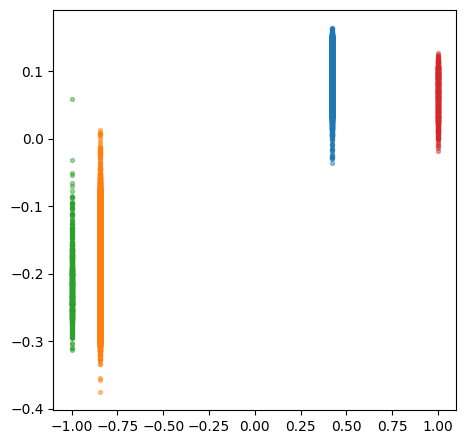

In [9]:
# 电荷准确度：q_ref vs q_pred（散点图 + MAE/RMSE/R^2）
import numpy as np
import matplotlib.pyplot as plt
def load_ref_charge_from_extxyz(path):
    q_blocks = []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            _ = f.readline()  # header
            q_now = []
            for _ in range(nat):
                parts = f.readline().split()
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                q_now.append(vals[6])
            q_blocks.append(np.asarray(q_now, dtype=np.float64))
    return np.concatenate(q_blocks, axis=0)
def predict_q_from_model(model, atomicdata_list, device="cpu"):
    model.eval()
    loader = torch_geometric.dataloader.DataLoader(
        atomicdata_list, batch_size=8, shuffle=False, drop_last=False
    )
    q_all = []
    q_key_used = None
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)
        if "q_eq" in out:
            q_key = "q_eq"
        elif "q" in out:
            q_key = "q"
        else:
            raise KeyError(f"model output keys have no 'q_eq' or 'q': {list(out.keys())}")
        q_key_used = q_key
        q_all.append(out[q_key].detach().cpu().numpy().reshape(-1))
    return np.concatenate(q_all, axis=0), q_key_used
q_ref = load_ref_charge_from_extxyz(str(DATA_PATH))
q_pred, q_key_used = predict_q_from_model(model, data_with_charge, device="cpu")
print("q key used:", q_key_used)
assert q_ref.shape == q_pred.shape, f"shape mismatch: q_ref={q_ref.shape}, q_pred={q_pred.shape}"
mae = float(np.mean(np.abs(q_ref - q_pred)))
rmse = float(np.sqrt(np.mean((q_ref - q_pred) ** 2)))
ss_res = float(np.sum((q_ref - q_pred) ** 2))
ss_tot = float(np.sum((q_ref - np.mean(q_ref)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
print("q MAE :", mae)
print("q RMSE:", rmse)
print("q R^2 :", r2)
print("q_ref range :", float(q_ref.min()), float(q_ref.max()))
print("q_pred range:", float(q_pred.min()), float(q_pred.max()))
# 对 Qeq 模型，q 常是归一化表征；给出按 norm_factor 还原后的误差
charge_eq_mod = None
for m in model.modules():
    if m.__class__.__name__ == "ChargeEq":
        charge_eq_mod = m
        break
if charge_eq_mod is not None and hasattr(charge_eq_mod, "normalization_factor"):
    nf = float(charge_eq_mod.normalization_factor)
    q_pred_scaled = q_pred * nf
    mae_scaled = float(np.mean(np.abs(q_ref - q_pred_scaled)))
    rmse_scaled = float(np.sqrt(np.mean((q_ref - q_pred_scaled) ** 2)))
    print("norm_factor:", nf)
    print("q MAE (scaled):", mae_scaled)
    print("q RMSE(scaled):", rmse_scaled)
# 只绘制 scaled q_pred，并按元素自动着色
# 元素序列与 q_ref / q_pred 顺序保持一致（按结构、按原子顺序展开）
elem_Z = np.concatenate([
    d.atomic_numbers.detach().cpu().numpy().reshape(-1)
    if hasattr(d.atomic_numbers, "detach")
    else np.asarray(d.atomic_numbers).reshape(-1)
    for d in data_with_charge
]).astype(int)
if charge_eq_mod is None or not hasattr(charge_eq_mod, "normalization_factor"):
    raise ValueError("ChargeEq normalization_factor not found; cannot draw scaled q_pred only.")
q_pred_scaled = q_pred * float(charge_eq_mod.normalization_factor)
assert elem_Z.shape[0] == q_ref.shape[0] == q_pred_scaled.shape[0], (
    f"shape mismatch: elem_Z={elem_Z.shape}, q_ref={q_ref.shape}, q_pred_scaled={q_pred_scaled.shape}"
)
z_to_symbol = {1: "H", 8: "O", 9: "F", 19: "K", 11: "Na", 17: "Cl"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
plt.figure(figsize=(5.2, 5.2))
for i, z in enumerate(sorted(np.unique(elem_Z))):
    mask = elem_Z == z
    if not np.any(mask):
        continue
    label = z_to_symbol.get(int(z), f"Z={int(z)}")
    plt.scatter(
        q_ref[mask],
        q_pred_scaled[mask],
        s=8,
        alpha=0.45,
        c=colors[i % len(colors)],
        label=label,
    )
# 电荷准确度：q_ref vs q_pred（散点图 + MAE/RMSE/R^2）
import numpy as np
import matplotlib.pyplot as plt
def load_ref_charge_from_extxyz(path):
    q_blocks = []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            _ = f.readline()  # header
            q_now = []
            for _ in range(nat):
                parts = f.readline().split()
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                q_now.append(vals[6])
            q_blocks.append(np.asarray(q_now, dtype=np.float64))
    return np.concatenate(q_blocks, axis=0)
def predict_q_from_model(model, atomicdata_list, device="cpu"):
    model.eval()
    loader = torch_geometric.dataloader.DataLoader(
        atomicdata_list, batch_size=8, shuffle=False, drop_last=False
    )
    q_all = []
    q_key_used = None
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)
        if "q_eq" in out:
            q_key = "q_eq"
        elif "q" in out:
            q_key = "q"
        else:
            raise KeyError(f"model output keys have no 'q_eq' or 'q': {list(out.keys())}")
        q_key_used = q_key
        q_all.append(out[q_key].detach().cpu().numpy().reshape(-1))
    return np.concatenate(q_all, axis=0), q_key_used
q_ref = load_ref_charge_from_extxyz(str(DATA_PATH))
q_pred, q_key_used = predict_q_from_model(model, data_with_charge, device="cpu")
print("q key used:", q_key_used)
assert q_ref.shape == q_pred.shape, f"shape mismatch: q_ref={q_ref.shape}, q_pred={q_pred.shape}"
mae = float(np.mean(np.abs(q_ref - q_pred)))
rmse = float(np.sqrt(np.mean((q_ref - q_pred) ** 2)))
ss_res = float(np.sum((q_ref - q_pred) ** 2))
ss_tot = float(np.sum((q_ref - np.mean(q_ref)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
print("q MAE :", mae)
print("q RMSE:", rmse)
print("q R^2 :", r2)
print("q_ref range :", float(q_ref.min()), float(q_ref.max()))
print("q_pred range:", float(q_pred.min()), float(q_pred.max()))
# 对 Qeq 模型，q 常是归一化表征；给出按 norm_factor 还原后的误差
charge_eq_mod = None
for m in model.modules():
    if m.__class__.__name__ == "ChargeEq":
        charge_eq_mod = m
        break
if charge_eq_mod is not None and hasattr(charge_eq_mod, "normalization_factor"):
    nf = float(charge_eq_mod.normalization_factor)
    q_pred_scaled = q_pred * nf
    mae_scaled = float(np.mean(np.abs(q_ref - q_pred_scaled)))
    rmse_scaled = float(np.sqrt(np.mean((q_ref - q_pred_scaled) ** 2)))
    print("norm_factor:", nf)
    print("q MAE (scaled):", mae_scaled)
    print("q RMSE(scaled):", rmse_scaled)
# 只绘制 scaled q_pred，并按元素自动着色
# 元素序列与 q_ref / q_pred 顺序保持一致（按结构、按原子顺序展开）
elem_Z = np.concatenate([
    d.atomic_numbers.detach().cpu().numpy().reshape(-1)
    if hasattr(d.atomic_numbers, "detach")
    else np.asarray(d.atomic_numbers).reshape(-1)
    for d in data_with_charge
]).astype(int)
if charge_eq_mod is None or not hasattr(charge_eq_mod, "normalization_factor"):
    raise ValueError("ChargeEq normalization_factor not found; cannot draw scaled q_pred only.")
q_pred_scaled = q_pred * float(charge_eq_mod.normalization_factor)
assert elem_Z.shape[0] == q_ref.shape[0] == q_pred_scaled.shape[0], (
    f"shape mismatch: elem_Z={elem_Z.shape}, q_ref={q_ref.shape}, q_pred_scaled={q_pred_scaled.shape}"
)


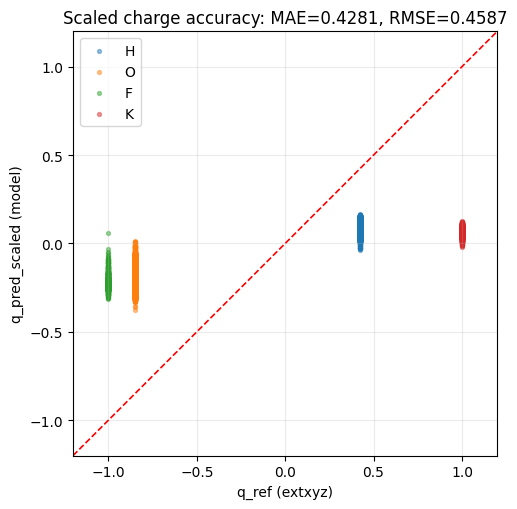

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 依赖前面已算好的变量：
# q_ref, q_pred_scaled, elem_Z, mae_scaled, rmse_scaled
# 若你的变量名不同，请对应替换

z_to_symbol = {1: "H", 8: "O", 9: "F", 19: "K", 11: "Na", 17: "Cl"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# 防止重复叠图：先清空当前图
plt.close("all")

fig, ax = plt.subplots(figsize=(5.2, 5.2))

for i, z in enumerate(sorted(np.unique(elem_Z))):
    mask = (elem_Z == z)
    if not np.any(mask):
        continue
    label = z_to_symbol.get(int(z), f"Z={int(z)}")
    ax.scatter(
        q_ref[mask],
        q_pred_scaled[mask],
        s=8,
        alpha=0.45,
        c=colors[i % len(colors)],
        label=label,
    )

# 轴范围：同时覆盖 q_ref 与 q_pred_scaled
xy_min = float(min(np.min(q_ref), np.min(q_pred_scaled)))
xy_max = float(max(np.max(q_ref), np.max(q_pred_scaled)))
pad = 0.10 * max(1e-8, (xy_max - xy_min))
lo, hi = xy_min - pad, xy_max + pad

ax.plot([lo, hi], [lo, hi], "r--", lw=1.2)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("q_ref (extxyz)")
ax.set_ylabel("q_pred_scaled (model)")
ax.set_title(f"Scaled charge accuracy: MAE={mae_scaled:.4f}, RMSE={rmse_scaled:.4f}")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()